# Drug-Target Interaction Prediction - Full Pipeline

**Dataset**: Davis Kinase Binding Affinity Dataset  
**Goal**: Predict binding affinity (pKd) between drug (SMILES) and protein (FASTA sequence)

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import os
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## 2. Load and Explore the Data

In [2]:
df1 = pd.read_csv('../data/raw/davis_all.csv')
df2 = pd.read_csv('../data/raw/kiba_all.csv')

In [3]:
df = pd.concat([df1, df2], ignore_index=True)

In [4]:
df.shape

(148310, 3)

In [5]:
df.head()

,compound_iso_smiles,target_sequence,affinity
0,O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,5.0
1,CSc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.0
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,MGPAPLPLLLGLFLPALWRRAITEAREEAKPYPLFPGPFPGSLQTD...,5.0
3,COC1C(N(C)C(=O)c2ccccc2)CC2OC1(C)n1c3ccccc3c3c...,MFRKKKKKRPEISAPQNFQHRVHTSFDPKEGKFVGLPPQWQNILDT...,5.0
4,CN(C)CC=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc...,TMPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLITI...,5.0


In [6]:
df.tail()

,compound_iso_smiles,target_sequence,affinity
148305,CN(C)c1cc2sncc2cc1NC(=O)C(=O)O,MSELEEDFAKILMLKEERIKELEKRLSEKEEEIQELKRKLHKCQSV...,11.800001
148306,CN1CCC1COc1cncc(CCc2ccncc2)c1,MAPFLRIAFNSYELGSLQAEDEANQPFCAVKMKEALSTERGKTLVQ...,11.200000
148307,O=C(CO)N1CCC(c2[nH]nc(-c3ccc(Cl)cc3F)c2-c2ccnc...,MSSWIRWHGPAMARLWGFCWLVVGFWRAAFACPTSCKCSASRIWCS...,11.400000
148308,NNc1cc(N2CCOCC2)nc(OCCc2ccccn2)n1,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,11.500000
148309,O=c1c(NCc2ccc(Cl)c(Cl)c2)c(Nc2ccncc2)c1=O,MADEDLIFRLEGVDGGQSPRAGHDGDSDGDSDDEEGYFICPITDDP...,11.500000


In [7]:
df['affinity'].describe()

count    148310.000000
mean         10.449602
std           2.658947
min           0.000000
25%          10.798970
50%          11.300000
75%          11.900001
max          17.200179
Name: affinity, dtype: float64

In [8]:
df["affinity"].max()

17.200179498

In [9]:
df["affinity"].value_counts()

affinity
5.000000     20931
11.200000    15046
11.100000    11961
11.900001     9949
11.300000     8358
             ...  
11.699530        1
11.483266        1
14.529635        1
12.302732        1
14.454983        1
Name: count, Length: 3340, dtype: int64

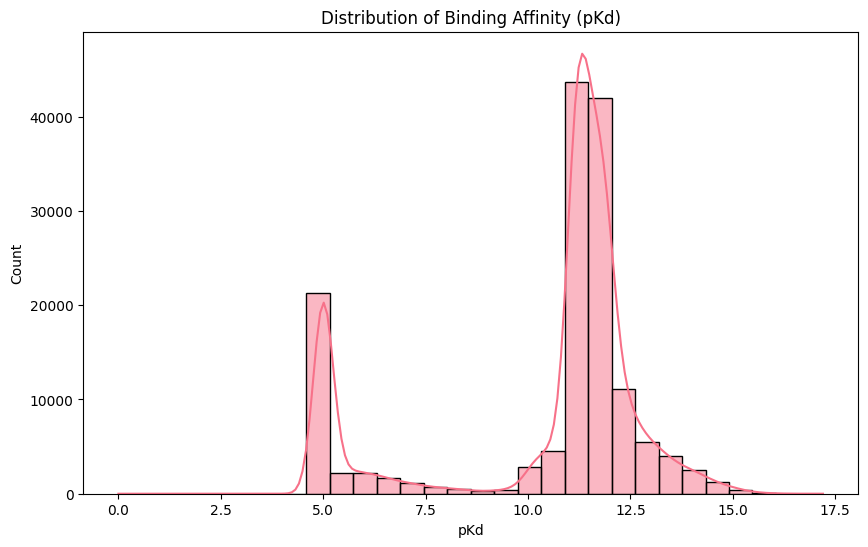

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['affinity'], kde=True, bins=30)
plt.title('Distribution of Binding Affinity (pKd)')
plt.xlabel('pKd')
plt.ylabel('Count')
plt.show()

## Normalize Davis + KIBA

In [11]:
davis = pd.read_csv('../data/raw/davis_all.csv')
kiba = pd.read_csv('../data/raw/kiba_all.csv')

In [12]:
davis.shape

(30056, 3)

In [13]:
kiba.shape

(118254, 3)

In [14]:
round(davis['affinity'].min(), 2)

5.0

In [15]:
round(davis['affinity'].max(), 2)

10.8

In [16]:
round(kiba['affinity'].min(), 2)

0.0

In [17]:
round(kiba['affinity'].max(), 2)

17.2

In [18]:
def normalize_affinity(df, name):
    df = df.copy()
    if name.lower() == 'kiba':
        min_val = df['affinity'].min()
        max_val = df['affinity'].max()
        df['affinity'] = 5 + 8 * (df['affinity'] - min_val) / (max_val - min_val)
    
    df['affinity'] = df['affinity'].clip(lower=5.0, upper=13.0)
    return df

In [19]:
davis_norm = normalize_affinity(davis, 'Davis')
kiba_norm = normalize_affinity(kiba, 'KIBA')

In [20]:
davis_norm

,compound_iso_smiles,target_sequence,affinity
0,O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,5.000000
1,CSc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.000000
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,MGPAPLPLLLGLFLPALWRRAITEAREEAKPYPLFPGPFPGSLQTD...,5.000000
3,COC1C(N(C)C(=O)c2ccccc2)CC2OC1(C)n1c3ccccc3c3c...,MFRKKKKKRPEISAPQNFQHRVHTSFDPKEGKFVGLPPQWQNILDT...,5.000000
4,CN(C)CC=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc...,TMPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLITI...,5.000000
...,...,...,...
30051,Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C...,MGAAAKLAFAVFLISCSSGAILGRSETQECLFFNANWEKDRTNQTG...,6.677781
30052,Cn1cnc2c(F)c(Nc3ccc(Br)cc3Cl)c(C(=O)NOCCO)cc21,MAGQPGHMPHGGSSNNLCHTLGPVHPPDPQRHPNTLSFRCSLADFQ...,5.000000
30053,Cc1ccc2nc(NCCN)c3ncc(C)n3c2c1.Cl,MKPATGLWVWVSLLVAAGTVQPSDSQSVCAGTENKLSSLSDLEQQY...,5.000000
30054,CC1(C)CNc2cc(NC(=O)c3cccnc3NCc3ccncc3)ccc21,MSRESDVEAQQSHGSSACSQPHGSVTQSQGSSSQSQGISSSSTSTM...,5.000000


In [21]:
kiba_norm

,compound_iso_smiles,target_sequence,affinity
0,O=C1c2c(c3c4ccc(O)cc4n(C4OC(CO)C(O)C(O)C4O)c3c...,MSANNSPPSAQKSVLPTAIPAVLPAASPCSSPKTGLSARLSNGSFS...,9.557613
1,N#Cc1ccc(NC(=O)Nc2ccnc3cc(C(F)(F)F)ccc23)nc1,MLGAVEGPRWKQAEDIRDIYDFRDVLGTGAFSEVILAEDKRTQKLV...,10.302270
2,CCNc1nc2cc(Cl)c(OC)cc2nc1NCC,MEPAAGFLSPRPFQRAAAAPAPPAGPGPPPSALRGPELEMLAGLPT...,10.209248
3,CNc1ncnc2c1N=C(c1ccc(NC(=O)Nc3cccc(C(F)(F)F)c3...,MELRVGNRYRLGRKIGSGSFGDIYLGTDIAAGEEVAIKLECVKTKH...,10.209248
4,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,MRGARGAWDFLCVLLLLLRVQTGSSQPSVSPGEPSPPSIHPGKSDL...,10.581336
...,...,...,...
118249,CN(C)c1cc2sncc2cc1NC(=O)C(=O)O,MSELEEDFAKILMLKEERIKELEKRLSEKEEEIQELKRKLHKCQSV...,10.488315
118250,CN1CCC1COc1cncc(CCc2ccncc2)c1,MAPFLRIAFNSYELGSLQAEDEANQPFCAVKMKEALSTERGKTLVQ...,10.209248
118251,O=C(CO)N1CCC(c2[nH]nc(-c3ccc(Cl)cc3F)c2-c2ccnc...,MSSWIRWHGPAMARLWGFCWLVVGFWRAAFACPTSCKCSASRIWCS...,10.302270
118252,NNc1cc(N2CCOCC2)nc(OCCc2ccccn2)n1,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,10.348781


In [22]:
merged_df = pd.concat([davis_norm, kiba_norm], ignore_index=True)

In [23]:
merged_df.shape

(148310, 3)

In [24]:
merged_df

,compound_iso_smiles,target_sequence,affinity
0,O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,5.000000
1,CSc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.000000
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,MGPAPLPLLLGLFLPALWRRAITEAREEAKPYPLFPGPFPGSLQTD...,5.000000
3,COC1C(N(C)C(=O)c2ccccc2)CC2OC1(C)n1c3ccccc3c3c...,MFRKKKKKRPEISAPQNFQHRVHTSFDPKEGKFVGLPPQWQNILDT...,5.000000
4,CN(C)CC=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc...,TMPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLITI...,5.000000
...,...,...,...
148305,CN(C)c1cc2sncc2cc1NC(=O)C(=O)O,MSELEEDFAKILMLKEERIKELEKRLSEKEEEIQELKRKLHKCQSV...,10.488315
148306,CN1CCC1COc1cncc(CCc2ccncc2)c1,MAPFLRIAFNSYELGSLQAEDEANQPFCAVKMKEALSTERGKTLVQ...,10.209248
148307,O=C(CO)N1CCC(c2[nH]nc(-c3ccc(Cl)cc3F)c2-c2ccnc...,MSSWIRWHGPAMARLWGFCWLVVGFWRAAFACPTSCKCSASRIWCS...,10.302270
148308,NNc1cc(N2CCOCC2)nc(OCCc2ccccn2)n1,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,10.348781


In [25]:
merged_df['affinity'].describe().round(2)

count    148310.00
mean          9.44
std           2.08
min           5.00
25%          10.02
50%          10.26
75%          10.53
max          13.00
Name: affinity, dtype: float64

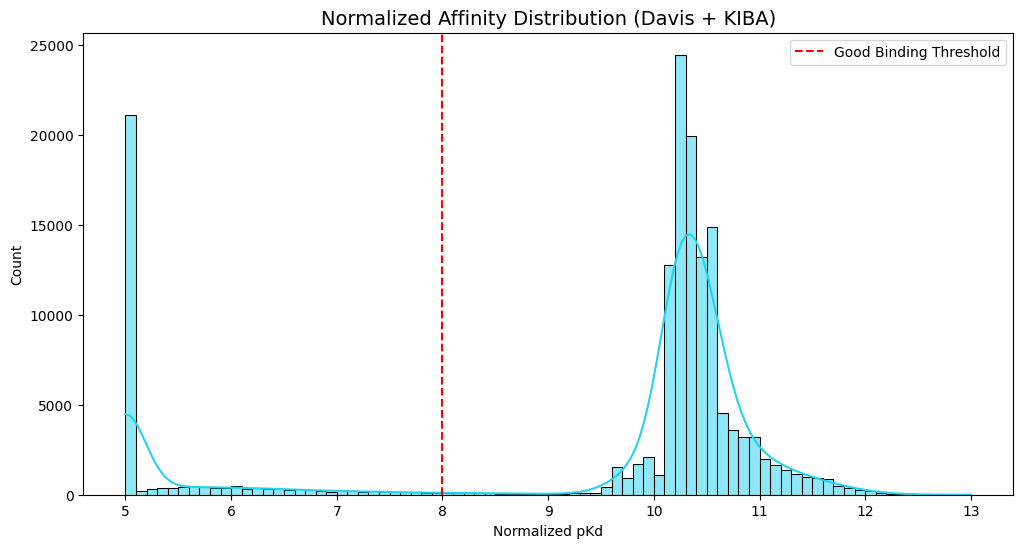

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(merged_df['affinity'], kde=True, bins=80, color='#22d3ee')
plt.title('Normalized Affinity Distribution (Davis + KIBA)', fontsize=14)
plt.xlabel('Normalized pKd')
plt.ylabel('Count')
plt.axvline(8, color='red', linestyle='--', label='Good Binding Threshold')
plt.legend()
plt.show()

In [27]:
merged_df.to_csv('../data/processed/merged_davis_kiba_normalized.csv', index=False)

In [28]:
sns.set_palette("husl")
plt.style.use('default')

In [29]:
merged_df = pd.read_csv('../data/processed/merged_davis_kiba_normalized.csv')

In [30]:
merged_df.shape

(148310, 3)

In [31]:
merged_df

,compound_iso_smiles,target_sequence,affinity
0,O=C(NC1CCNCC1)c1[nH]ncc1NC(=O)c1c(Cl)cccc1Cl,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,5.000000
1,CSc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,5.000000
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,MGPAPLPLLLGLFLPALWRRAITEAREEAKPYPLFPGPFPGSLQTD...,5.000000
3,COC1C(N(C)C(=O)c2ccccc2)CC2OC1(C)n1c3ccccc3c3c...,MFRKKKKKRPEISAPQNFQHRVHTSFDPKEGKFVGLPPQWQNILDT...,5.000000
4,CN(C)CC=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc...,TMPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLITI...,5.000000
...,...,...,...
148305,CN(C)c1cc2sncc2cc1NC(=O)C(=O)O,MSELEEDFAKILMLKEERIKELEKRLSEKEEEIQELKRKLHKCQSV...,10.488315
148306,CN1CCC1COc1cncc(CCc2ccncc2)c1,MAPFLRIAFNSYELGSLQAEDEANQPFCAVKMKEALSTERGKTLVQ...,10.209248
148307,O=C(CO)N1CCC(c2[nH]nc(-c3ccc(Cl)cc3F)c2-c2ccnc...,MSSWIRWHGPAMARLWGFCWLVVGFWRAAFACPTSCKCSASRIWCS...,10.302270
148308,NNc1cc(N2CCOCC2)nc(OCCc2ccccn2)n1,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,10.348781


In [32]:
def extract_drug_features(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return {
        'mol_weight': Descriptors.MolWt(mol),
        'logp': Descriptors.MolLogP(mol),
        'num_h_donors': Lipinski.NumHDonors(mol),
        'num_h_acceptors': Lipinski.NumHAcceptors(mol),
        'num_rotatable_bonds': Lipinski.NumRotatableBonds(mol),
        'tpsa': Descriptors.TPSA(mol),
        'num_rings': Descriptors.RingCount(mol),
    }

In [33]:
def extract_protein_features(fasta):
    seq = str(fasta).strip()
    if seq.startswith('>'):
        seq = seq.split('\n', 1)[-1]
    seq = seq.replace('\n', '').strip()
    return {
        'protein_length': len(seq),
        'num_basic': seq.count('K') + seq.count('R') + seq.count('H'),
        'num_acidic': seq.count('D') + seq.count('E'),
    }

In [34]:
features = []
for idx, row in merged_df.iterrows():
    if idx % 10000 == 0 and idx > 0:
        print(f"  Processed {idx:,} pairs...")
    
    drug_feat = extract_drug_features(row['compound_iso_smiles'])
    if drug_feat is None:
        continue
    prot_feat = extract_protein_features(row['target_sequence'])
    
    combined = {**drug_feat, **prot_feat, 'affinity': row['affinity']}
    features.append(combined)

  Processed 10,000 pairs...
  Processed 20,000 pairs...
  Processed 30,000 pairs...
  Processed 40,000 pairs...
  Processed 50,000 pairs...
  Processed 60,000 pairs...
  Processed 70,000 pairs...
  Processed 80,000 pairs...
  Processed 90,000 pairs...
  Processed 100,000 pairs...
  Processed 110,000 pairs...
  Processed 120,000 pairs...
  Processed 130,000 pairs...
  Processed 140,000 pairs...


In [35]:
processed_df = pd.DataFrame(features)

In [36]:
processed_df

,mol_weight,logp,num_h_donors,num_h_acceptors,num_rotatable_bonds,tpsa,num_rings,protein_length,num_basic,num_acidic,affinity
0,382.251,2.4506,4,4,4,98.91,3,1338,199,151,5.000000
1,443.359,5.7678,1,6,4,59.81,4,790,96,80,5.000000
2,446.910,4.2756,1,7,8,68.74,4,999,110,110,5.000000
3,570.649,5.9068,1,6,3,77.73,9,681,100,63,5.000000
4,485.947,4.3899,2,7,8,88.61,4,1069,161,134,5.000000
...,...,...,...,...,...,...,...,...,...,...,...
148305,265.294,1.3854,2,5,2,82.53,2,671,105,104,10.488315
148306,283.375,2.3447,0,4,6,38.25,3,676,111,89,10.209248
148307,415.856,3.0245,2,5,4,95.00,4,822,104,89,10.302270
148308,316.365,0.6153,2,8,6,98.42,3,970,142,102,10.348781


In [37]:
processed_df.to_csv('../data/processed/final_processed_features.csv', index=False)

## Train XGBoost

In [38]:
X = processed_df.drop('affinity', axis=1)
y = processed_df['affinity']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
X_train

,mol_weight,logp,num_h_donors,num_h_acceptors,num_rotatable_bonds,tpsa,num_rings,protein_length,num_basic,num_acidic
60603,415.522,5.29994,3,5,2,92.93,5,1354,245,247
88687,349.209,3.95000,1,4,3,65.21,3,1114,145,132
103492,366.730,4.94600,2,3,2,66.91,3,464,85,57
121640,358.441,3.89650,2,3,4,58.20,4,802,131,105
906,464.599,3.50322,3,8,7,102.07,5,721,100,122
...,...,...,...,...,...,...,...,...,...,...
119879,377.356,4.28530,3,6,3,113.73,4,292,46,38
103694,430.418,4.40020,2,5,5,88.49,5,846,126,96
131932,270.336,2.57650,2,4,3,70.67,3,427,58,46
146867,511.631,-0.61800,8,7,16,205.54,3,697,105,83


In [41]:
X_test

,mol_weight,logp,num_h_donors,num_h_acceptors,num_rotatable_bonds,tpsa,num_rings,protein_length,num_basic,num_acidic
128899,460.490,3.24300,5,6,6,128.79,4,481,119,69
110610,227.227,1.36810,3,5,0,92.93,3,292,46,38
136471,375.410,0.51158,3,7,6,161.19,2,603,102,71
128199,413.069,3.33690,3,3,3,70.23,2,292,46,38
79838,301.781,3.48390,1,5,1,69.62,3,1210,157,138
...,...,...,...,...,...,...,...,...,...,...
57742,348.193,3.12660,3,4,3,110.68,3,445,85,67
34181,416.551,3.89580,3,8,9,119.00,3,878,118,97
98982,622.428,2.88490,4,9,5,152.11,7,890,127,107
8138,370.384,3.51844,2,6,5,84.67,4,737,119,101


In [42]:
y_test

128899    10.627848
110610    10.581336
136471    10.209248
128199    10.860403
79838     10.778995
            ...    
57742     10.162737
34181     10.441803
98982      9.601428
8138       5.000000
88949     10.162737
Name: affinity, Length: 29662, dtype: float64

In [43]:
y_train

60603     10.627848
88687     10.581336
103492    10.348781
121640    10.488315
906        5.000000
            ...    
119879    11.418564
103694    10.674359
131932    10.162737
146867    10.207811
121958    10.534826
Name: affinity, Length: 118648, dtype: float64

In [44]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [45]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [46]:
y_pred = model.predict(X_test)

In [47]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [48]:
rmse

0.5785780288185463

In [49]:
mae = mean_absolute_error(y_test, y_pred)

In [50]:
mae

0.27758804389200525

In [51]:
r2 = r2_score(y_test, y_pred)

In [52]:
r2

0.9216771263619962

In [53]:
print("\n" + "="*50)
print("✅ XGBoost Performance (Normalized Data)")
print("="*50)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")


✅ XGBoost Performance (Normalized Data)
RMSE : 0.5786
MAE  : 0.2776
R²   : 0.9217


In [54]:
joblib.dump(model, '../models/saved/dti_xgboost_normalized.pkl')

['../models/saved/dti_xgboost_normalized.pkl']

## K-fold Cross Validation

In [55]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [56]:
rmse_scores = []
mae_scores = []
r2_scores = []

In [57]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f"\n--- Fold {fold} ---")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")


--- Fold 1 ---
RMSE : 0.5798
MAE  : 0.2765
R²   : 0.9213

--- Fold 2 ---
RMSE : 0.5849
MAE  : 0.2773
R²   : 0.9202

--- Fold 3 ---
RMSE : 0.5913
MAE  : 0.2811
R²   : 0.9183

--- Fold 4 ---
RMSE : 0.5836
MAE  : 0.2801
R²   : 0.9222

--- Fold 5 ---
RMSE : 0.5727
MAE  : 0.2765
R²   : 0.9252


In [58]:
print("\n" + "="*60)
print("✅ FINAL CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Mean RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Mean MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Mean R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print("="*60)


✅ FINAL CROSS-VALIDATION RESULTS
Mean RMSE  : 0.5825 ± 0.0061
Mean MAE   : 0.2783 ± 0.0019
Mean R²    : 0.9215 ± 0.0023


In [59]:
joblib.dump(model, '../models/saved/dti_xgboost_final.pkl')

['../models/saved/dti_xgboost_final.pkl']

In [60]:
model.feature_importances_

array([0.12447617, 0.13853729, 0.14470503, 0.12502505, 0.10240929,
       0.20869826, 0.13218284, 0.0078995 , 0.00803746, 0.00802913],
      dtype=float32)